# 02 — Graph Convolutional Networks (GCN)

This notebook develops the Graph Convolutional Network from normalized adjacency to node classification.

**Adjacency** → **Self-loops** → **Degree normalization** → **GCN layer** → **Manual matrix calculation** → **From-scratch implementation** → **Cora**

## 1. Why not use $AXW$ directly?

A simple graph layer could use:

$$
AXW
$$

but it has two immediate limitations:

1. a node does not automatically preserve its own features,
2. high-degree nodes can accumulate much larger values than low-degree nodes.

GCN addresses these issues using **self-loops** and **degree normalization**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3,suppress=True)

## 2. Add self-loops

$$
\tilde{A}=A+I
$$

Adding $I$ makes every node part of its own neighborhood.

In [2]:
A = np.array([
    [0,1,1,0],
    [1,0,1,1],
    [1,1,0,1],
    [0,1,1,0]
],dtype=float)

I = np.eye(A.shape[0])
A_tilde = A+I

print("A:")
print(A)
print()
print("A_tilde:")
print(A_tilde)

A:
[[0. 1. 1. 0.]
 [1. 0. 1. 1.]
 [1. 1. 0. 1.]
 [0. 1. 1. 0.]]

A_tilde:
[[1. 1. 1. 0.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [0. 1. 1. 1.]]


## 3. Compute the degree matrix

$$
\tilde{D}_{ii}
=
\sum_j\tilde{A}_{ij}
$$

In [3]:
degree_tilde = A_tilde.sum(axis=1)
D_tilde = np.diag(degree_tilde)

print("Degrees:",degree_tilde)
print()
print("D_tilde:")
print(D_tilde)

Degrees: [3. 4. 4. 3.]

D_tilde:
[[3. 0. 0. 0.]
 [0. 4. 0. 0.]
 [0. 0. 4. 0.]
 [0. 0. 0. 3.]]


## 4. Symmetric normalization

GCN uses:

$$
\hat{A}
=
\tilde{D}^{-\frac12}
\tilde{A}
\tilde{D}^{-\frac12}
$$

This controls the scale of neighborhood aggregation.

In [4]:
D_inv_sqrt = np.diag(1.0/np.sqrt(degree_tilde))
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

print("D_tilde^(-1/2):")
print(D_inv_sqrt)
print()
print("A_hat:")
print(A_hat)

D_tilde^(-1/2):
[[0.577 0.    0.    0.   ]
 [0.    0.5   0.    0.   ]
 [0.    0.    0.5   0.   ]
 [0.    0.    0.    0.577]]

A_hat:
[[0.333 0.289 0.289 0.   ]
 [0.289 0.25  0.25  0.289]
 [0.289 0.25  0.25  0.289]
 [0.    0.289 0.289 0.333]]


## 5. GCN layer equation

$$
H^{(l+1)}
=
\sigma
\left(
\hat{A}H^{(l)}W^{(l)}
\right)
$$

At the input:

$$
H^{(0)}=X
$$

where $X$ is the node-feature matrix.

## 6. Complete manual matrix calculation

Use:

$$
H^{(0)}
=
\begin{bmatrix}
1 & 0\\
0 & 1\\
1 & 1\\
2 & 1
\end{bmatrix}
$$

and:

$$
W^{(0)}
=
\begin{bmatrix}
0.5 & -0.3\\
0.8 & 0.2
\end{bmatrix}
$$

We compute:

$$
H^{(0)}W^{(0)}
$$

then:

$$
\hat{A}H^{(0)}W^{(0)}
$$

and finally apply ReLU.

In [5]:
H0 = np.array([
    [1.0,0.0],
    [0.0,1.0],
    [1.0,1.0],
    [2.0,1.0]
])

W0 = np.array([
    [0.5,-0.3],
    [0.8,0.2]
])

HW = H0 @ W0
Z = A_hat @ HW
H1 = np.maximum(Z,0)

print("H0 @ W0:")
print(HW)
print()
print("A_hat @ H0 @ W0:")
print(Z)
print()
print("ReLU output H1:")
print(H1)

H0 @ W0:
[[ 0.5 -0.3]
 [ 0.8  0.2]
 [ 1.3 -0.1]
 [ 1.8 -0.4]]

A_hat @ H0 @ W0:
[[ 0.773 -0.071]
 [ 1.189 -0.177]
 [ 1.189 -0.177]
 [ 1.206 -0.104]]

ReLU output H1:
[[0.773 0.   ]
 [1.189 0.   ]
 [1.189 0.   ]
 [1.206 0.   ]]


## 7. Inspect one node's aggregation

For node 0, each nonzero entry in the first row of $\hat{A}$ is the coefficient used to combine a transformed node representation.

In [6]:
node = 0
weights = A_hat[node]
contributions = weights[:,None]*HW

print("Normalized coefficients:",weights)
print()
print("Per-node contributions:")
print(contributions)
print()
print("Summed result:",contributions.sum(axis=0))
print("Direct result:",Z[node])

Normalized coefficients: [0.333 0.289 0.289 0.   ]

Per-node contributions:
[[ 0.167 -0.1  ]
 [ 0.231  0.058]
 [ 0.375 -0.029]
 [ 0.    -0.   ]]

Summed result: [ 0.773 -0.071]
Direct result: [ 0.773 -0.071]


## 8. Implement the same GCN layer in PyTorch

This implementation does not use PyTorch Geometric. The normalized adjacency matrix is supplied explicitly.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

class GCNLayer(nn.Module):
    def __init__(self,in_features,out_features):
        super().__init__()
        self.linear = nn.Linear(in_features,out_features,bias=False)

    def forward(self,x,adj_norm):
        return adj_norm @ self.linear(x)

x_t = torch.tensor(H0,dtype=torch.float32)
adj_t = torch.tensor(A_hat,dtype=torch.float32)

layer = GCNLayer(2,2)

with torch.no_grad():
    layer.linear.weight.copy_(torch.tensor(W0.T,dtype=torch.float32))

output = F.relu(layer(x_t,adj_t))
print(output)

tensor([[0.7729, 0.0000],
        [1.1890, 0.0000],
        [1.1890, 0.0000],
        [1.2062, 0.0000]], grad_fn=<ReluBackward0>)


## 9. Cora node classification

Cora is a citation network:

- nodes are scientific papers,
- edges are citation relationships,
- node features describe documents,
- the target is the paper category.

We will compare a feature-only MLP with a graph-aware GCN using the same split.

In [11]:
# Uncomment in Google Colab if needed:
!pip -q install torch-geometric

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

dataset = Planetoid(root="data/Planetoid",name="Cora")
data = dataset[0]

print(data)
print()
print("Nodes:",data.num_nodes)
print("Edges:",data.num_edges)
print("Features:",dataset.num_node_features)
print("Classes:",dataset.num_classes)

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

Nodes: 2708
Edges: 10556
Features: 1433
Classes: 7


Done!


## 10. Feature-only MLP baseline

In [12]:
class NodeMLP(nn.Module):
    def __init__(self,in_dim,hidden_dim,out_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim,hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,out_dim)

    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x,p=0.5,training=self.training)
        return self.fc2(x)

mlp = NodeMLP(dataset.num_node_features,32,dataset.num_classes)

## 11. Two-layer GCN

In [13]:
class GCN(nn.Module):
    def __init__(self,in_dim,hidden_dim,out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim,hidden_dim)
        self.conv2 = GCNConv(hidden_dim,out_dim)

    def forward(self,x,edge_index,return_embedding=False):
        x = self.conv1(x,edge_index)
        x = F.relu(x)
        embedding = x
        x = F.dropout(x,p=0.5,training=self.training)
        x = self.conv2(x,edge_index)

        if return_embedding:
            return x,embedding

        return x

gcn = GCN(dataset.num_node_features,32,dataset.num_classes)

## 12. Training utilities

In [14]:
def accuracy_from_logits(logits,y,mask):
    pred = logits[mask].argmax(dim=1)
    return (pred == y[mask]).float().mean().item()

def train_model(model,data,use_graph,epochs=200):
    optimizer = torch.optim.Adam(model.parameters(),lr=0.01,weight_decay=5e-4)
    history = {"loss":[],"train_acc":[],"val_acc":[]}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        if use_graph:
            logits = model(data.x,data.edge_index)
        else:
            logits = model(data.x)

        loss = F.cross_entropy(logits[data.train_mask],data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            if use_graph:
                logits = model(data.x,data.edge_index)
            else:
                logits = model(data.x)

        history["loss"].append(loss.item())
        history["train_acc"].append(accuracy_from_logits(logits,data.y,data.train_mask))
        history["val_acc"].append(accuracy_from_logits(logits,data.y,data.val_mask))

    return history

In [15]:
mlp_history = train_model(mlp,data,use_graph=False)
gcn_history = train_model(gcn,data,use_graph=True)

## 13. Validation accuracy comparison

This plot directly tests whether using graph connectivity improves node classification compared with using node features alone.

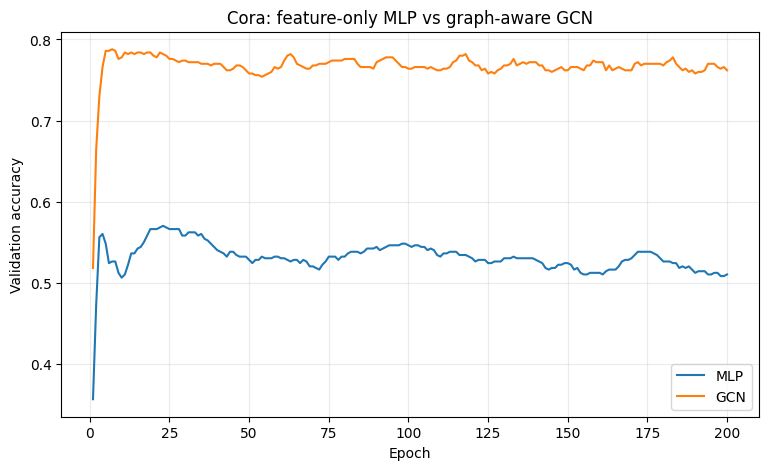

In [16]:
epochs = np.arange(1,len(gcn_history["val_acc"])+1)

plt.figure(figsize=(9,5))
plt.plot(epochs,mlp_history["val_acc"],label="MLP")
plt.plot(epochs,gcn_history["val_acc"],label="GCN")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Cora: feature-only MLP vs graph-aware GCN")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 14. Test evaluation

In [17]:
mlp.eval()
gcn.eval()

with torch.no_grad():
    mlp_logits = mlp(data.x)
    gcn_logits,gcn_embedding = gcn(data.x,data.edge_index,return_embedding=True)

mlp_test_acc = accuracy_from_logits(mlp_logits,data.y,data.test_mask)
gcn_test_acc = accuracy_from_logits(gcn_logits,data.y,data.test_mask)

results = pd.DataFrame({
    "Model":["MLP","GCN"],
    "Test accuracy":[mlp_test_acc,gcn_test_acc]
})

print(results)

  Model  Test accuracy
0   MLP          0.528
1   GCN          0.809


## 15. Learned node embeddings

A 2D PCA projection compresses the hidden GCN representation for visualization.

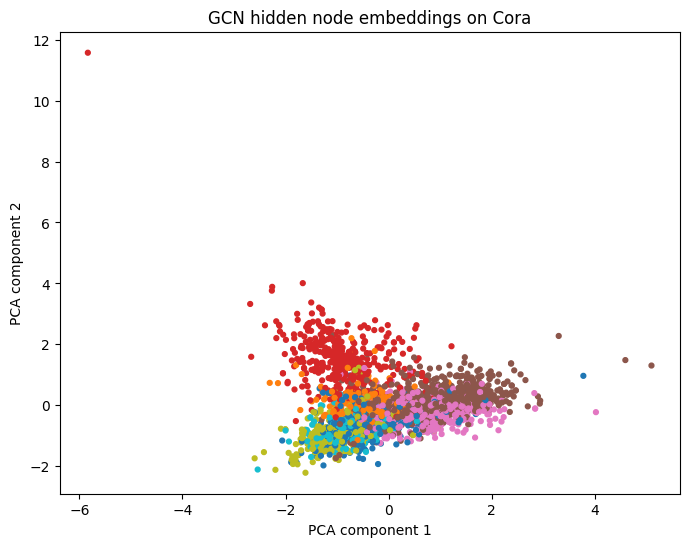

In [18]:
from sklearn.decomposition import PCA

embedding_2d = PCA(n_components=2).fit_transform(gcn_embedding.detach().cpu().numpy())
labels = data.y.cpu().numpy()

plt.figure(figsize=(8,6))
plt.scatter(embedding_2d[:,0],embedding_2d[:,1],c=labels,s=12,cmap="tab10")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("GCN hidden node embeddings on Cora")
plt.show()

## 16. Key takeaways

1. Self-loops preserve a node's own information.
2. Symmetric degree normalization stabilizes neighborhood mixing.
3. GCN combines graph propagation with trainable feature transformation.
4. The manual matrix calculation and PyTorch implementation perform the same core operation.
5. The MLP comparison isolates the value of graph connectivity.
6. The next notebook introduces GraphSAGE and inductive aggregation.